## What is the most optimal skill to learn for Data Analysts?
### Methodology
1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [1]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns 

# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# # data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [47]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset = 'salary_year_avg')

df_DA_US_EX = df_DA_US.explode('job_skills')

df_DA_Top_Skills = df_DA_US_EX.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

In [48]:
df_DA_Top_Skills = df_DA_Top_Skills.sort_values(by='count', ascending=False)
df_DA_Top_Skills = df_DA_Top_Skills.rename(columns={'median':'median_salary','count':'skill_count'})

In [49]:
job_count = len(df_DA_US)
df_DA_Top_Skills['Percentage'] = df_DA_Top_Skills['skill_count']/job_count * 100

In [55]:
Top_Percent = 5
df_DA_Top_Skills = df_DA_Top_Skills[df_DA_Top_Skills['Percentage']>Top_Percent]

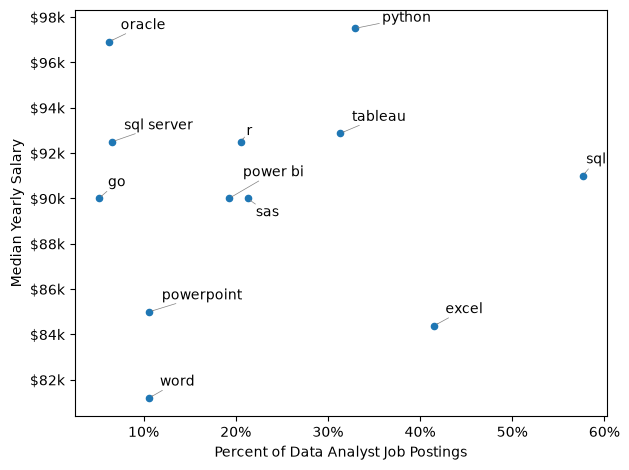

In [142]:
from adjustText import adjust_text

df_DA_Top_Skills.plot(kind='scatter', x='Percentage', y='median_salary')

plt.ylabel('Median Yearly Salary')
plt.xlabel('Percent of Data Analyst Job Postings')
texts = []
for i,title in enumerate(df_DA_Top_Skills.index):
    texts.append(plt.text(x=df_DA_Top_Skills['Percentage'].iloc[i], y=df_DA_Top_Skills['median_salary'].iloc[i],
    s = title))

adjust_text(texts,expand=(2,2),arrowprops=dict(arrowstyle='->',color='gray',lw=0.5))

ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'{int(x)}%'))

plt.tight_layout()


In [73]:
df_DA_US['job_type_skills'] = df_DA_US['job_type_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_technology = df_DA_US['job_type_skills']
df_technology = df_technology.dropna()

tech_dict = {}

for row in df_technology:
    for key,value in row.items():
        if key in tech_dict:
            tech_dict[key] += value
        else:
            tech_dict[key] = value

for key,value in tech_dict.items():
    tech_dict[key] = list(set(value))

tech_dict

In [139]:
df_Technology = pd.DataFrame(list(tech_dict.items()), columns=['technology','skills'])
df_Technology = df_Technology.explode('skills')

In [165]:
df_Plot = df_DA_Top_Skills.merge(df_Technology, left_on='job_skills', right_on='skills')
df_Plot = df_Plot[~((df_Plot['skills'] == 'sas') & (df_Plot['technology'] == 'analyst_tools'))]

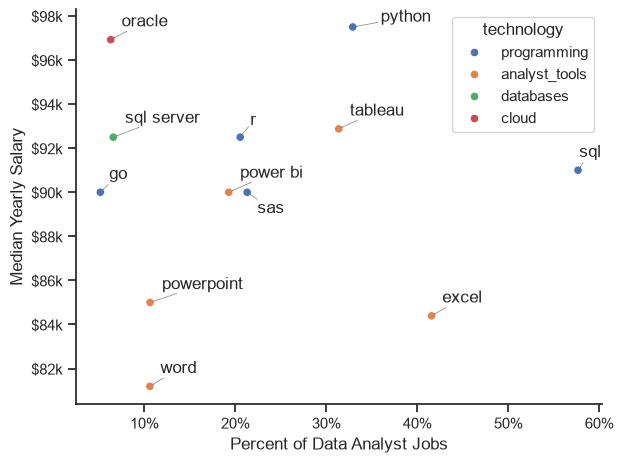

In [167]:
from adjustText import adjust_text

# df_DA_Top_Skills.plot(kind='scatter', x='Percentage', y='median_salary')
sns.scatterplot(data=df_Plot, x='Percentage', y='median_salary', hue='technology')

sns.despine()
sns.set_theme(style='ticks')

plt.ylabel('Median Yearly Salary')
plt.xlabel('Percent of Data Analyst Jobs')
texts = []
for i,title in enumerate(df_Plot['skills']):
    texts.append(plt.text(x=df_Plot['Percentage'].iloc[i], y=df_Plot['median_salary'].iloc[i],
    s = title))

adjust_text(texts,expand=(2,2),arrowprops=dict(arrowstyle='->',color='gray',lw=0.5))

ax = plt.gca()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'{int(x)}%'))

plt.tight_layout()
